PCD KELOMPOK 3 FIXXX BENAR


In [ ]:
# ===============================================================
# 1. IMPORT & KONFIGURASI
# ===============================================================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json

# Cek GPU
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# --- PATH DATASET ---
base_dir   = r"../Dataset"   # <--- SESUAIKAN PATH INI
train_dir  = os.path.join(base_dir, "train")
val_dir    = os.path.join(base_dir, "validation")
test_dir   = os.path.join(base_dir, "DataTest")
output_dir = os.path.join("src", "output_final")

os.makedirs(output_dir, exist_ok=True)

# --- PARAMETER ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ===============================================================
# 2. DATA GENERATOR (AUGMENTASI KUAT / AGRESIF)
# ===============================================================
print("\n[INFO] Menyiapkan Data Generator...")

# Augmentasi diperkuat untuk melawan Overfitting
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Wajib untuk EfficientNet
    rotation_range=40,         # Putar ekstrem
    width_shift_range=0.2,     # Geser horizontal
    height_shift_range=0.2,    # Geser vertikal
    shear_range=0.2,           # Miringkan
    zoom_range=0.3,            # Zoom in/out
    brightness_range=[0.7, 1.3], # Variasi pencahayaan (PENTING untuk kulit)
    horizontal_flip=True,
    vertical_flip=True,        # Kulit bisa dibalik atas-bawah
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load Data
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Simpan Mapping Kelas
with open(os.path.join(output_dir, "class_indices.json"), "w") as f:
    json.dump(train_generator.class_indices, f, indent=4)
    
print(f"✅ Kelas: {list(train_generator.class_indices.keys())}")

# ===============================================================
# 3. BUILD MODEL (DENGAN REGULARISASI)
# ===============================================================
def build_robust_model():
    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # Base Model: EfficientNetB0
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)
    base_model.trainable = False # Freeze awal
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    # Head dengan Regularisasi Kuat
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)  # Dropout tinggi (50%)
    
    # Dense Layer dengan L2 Regularization (Mencegah bobot terlalu besar)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(train_generator.num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Robust")
    return model, base_model

model, base_model_obj = build_robust_model()

# Compile Awal
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================================================
# 4. STAGE 1: TRAINING HEAD
# ===============================================================
print("\n" + "="*40)
print("🚀 STAGE 1: Training Head Only")
print("="*40)

callbacks_stage1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20, # Pemanasan
    callbacks=callbacks_stage1
)

# ===============================================================
# 5. STAGE 2: FINE TUNING
# ===============================================================
print("\n" + "="*40)
print("🔓 STAGE 2: Fine Tuning (Unfreeze & Retrain)")
print("="*40)

# Unfreeze Base Model
base_model_obj.trainable = True

# Freeze ulang layer bawah, sisakan 50 layer atas
fine_tune_at = len(base_model_obj.layers) - 50
for layer in base_model_obj.layers[:fine_tune_at]:
    layer.trainable = False

print(f"✓ Total Layer: {len(base_model_obj.layers)}")
print(f"✓ Layer Frozen: {fine_tune_at}")
print(f"✓ Layer Trainable: {len(base_model_obj.layers) - fine_tune_at}")

# Compile Ulang dengan LR Kecil
model.compile(
    optimizer=Adam(learning_rate=1e-5), # LR sangat kecil agar tidak merusak bobot
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks_stage2 = [
    ModelCheckpoint(os.path.join(output_dir, "best_skin_model.h5"), save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

# Lanjutkan Training
history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    initial_epoch=history1.epoch[-1],
    epochs=100, # Total epoch (termasuk stage 1)
    callbacks=callbacks_stage2
)

# ===============================================================
# 6. VISUALISASI HASIL
# ===============================================================
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.axvline(x=len(history1.history['accuracy'])-1, color='green', linestyle='--', label='Start Fine Tuning')
plt.legend()
plt.title('Accuracy History')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history1.history['loss'])-1, color='green', linestyle='--', label='Start Fine Tuning')
plt.legend()
plt.title('Loss History')
plt.show()

# ===============================================================
# 7. EVALUASI DATA TEST (MANUAL)
# ===============================================================
print("\n" + "="*40)
print("🔍 EVALUASI DATA TEST (REAL WORLD)")
print("="*40)

def predict_image(model, path):
    try:
        img = load_img(path, target_size=IMG_SIZE)
        img_arr = img_to_array(img)
        img_arr = preprocess_input(img_arr) # Preprocess EfficientNet
        img_batch = np.expand_dims(img_arr, axis=0)
        return np.argmax(model.predict(img_batch, verbose=0))
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return -1

y_test_true = []
y_test_pred = []
class_names = list(train_generator.class_indices.keys())

# Scan Folder Test
files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not files:
    print("⚠ Folder Test kosong!")
else:
    print(f"Memproses {len(files)} gambar test...")
    for fname in files:
        # Ambil label dari nama file (Misal: "Eczema (1).jpg" -> "Eczema")
        label_str = fname.split(" ")[0] 
        
        if label_str in class_names:
            true_idx = class_names.index(label_str)
            pred_idx = predict_image(model, os.path.join(test_dir, fname))
            
            if pred_idx != -1:
                y_test_true.append(true_idx)
                y_test_pred.append(pred_idx)
        else:
            print(f"⚠ Skip: '{fname}' (Label '{label_str}' tidak dikenal)")

    # Tampilkan Hasil
    if y_test_true:
        acc_test = np.mean(np.array(y_test_true) == np.array(y_test_pred)) * 100
        print(f"\n🏆 TEST ACCURACY: {acc_test:.2f}%")
        
        all_labels = np.arange(len(class_names))
        print(classification_report(y_test_true, y_test_pred, target_names=class_names, labels=all_labels, zero_division=0))
        
        cm = confusion_matrix(y_test_true, y_test_pred, labels=all_labels)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix Test (Acc: {acc_test:.2f}%)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()
    else:
        print("⚠ Tidak ada data valid untuk dievaluasi.")

TensorFlow Version: 2.20.0
GPU Available: False

[INFO] Menyiapkan Data Generator...
Found 560 images belonging to 4 classes.
Found 156 images belonging to 4 classes.
✅ Kelas: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


Model: "EfficientNet_Robust"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


🚀 STAGE 1: Training Head Only
Epoch 1/20
 6/18 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2925 - loss: 6.8594


EVALUASI DATA TRAINING
Found 560 images belonging to 4 classes.
⏳ Memprediksi Confusion Matrix - Training Data...
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 563ms/step

📊 CLASSIFICATION REPORT: Confusion Matrix - Training Data
                       precision    recall  f1-score   support

Tomato___Early_blight       0.92      0.94      0.93       140
 Tomato___Late_blight       0.97      0.88      0.92       140
   Tomato___Leaf_Mold       0.93      0.98      0.95       140
     Tomato___healthy       0.97      1.00      0.99       140

             accuracy                           0.95       560
            macro avg       0.95      0.95      0.95       560
         weighted avg       0.95      0.95      0.95       560



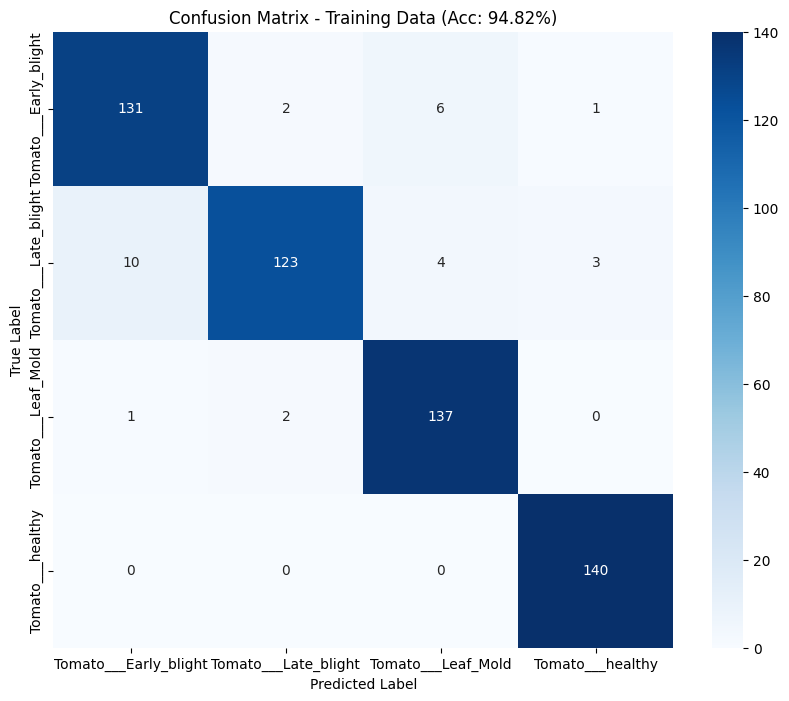


EVALUASI DATA VALIDATION
⏳ Memprediksi Confusion Matrix - Validation Data...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step

📊 CLASSIFICATION REPORT: Confusion Matrix - Validation Data
                       precision    recall  f1-score   support

Tomato___Early_blight       0.96      0.69      0.81        39
 Tomato___Late_blight       0.80      0.90      0.84        39
   Tomato___Leaf_Mold       0.82      0.95      0.88        39
     Tomato___healthy       1.00      1.00      1.00        39

             accuracy                           0.88       156
            macro avg       0.90      0.88      0.88       156
         weighted avg       0.90      0.88      0.88       156



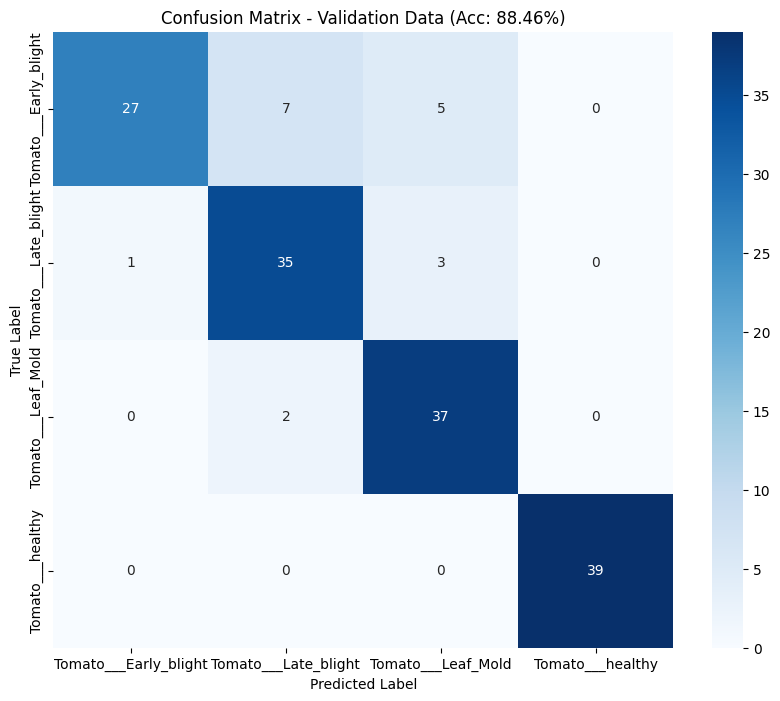

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ===============================================================
# FUNGSI BANTUAN UNTUK PLOT CONFUSION MATRIX
# ===============================================================
def evaluate_and_plot(model, generator, title="Confusion Matrix"):
    # 1. Reset Generator & Pastikan Shuffle False
    # Generator harus di-reset ke awal agar urutan data konsisten
    generator.reset() 
    
    # 2. Prediksi
    print(f"⏳ Memprediksi {title}...")
    y_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_probs, axis=1)
    
    # 3. Ambil Label Asli
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())
    
    # 4. Report
    print(f"\n📊 CLASSIFICATION REPORT: {title}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 5. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} (Acc: {np.mean(y_true == y_pred)*100:.2f}%)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ===============================================================
# 1. EVALUASI DATA TRAINING
# ===============================================================
# KITA WAJIB LOAD ULANG TRAIN DATA DENGAN SHUFFLE=FALSE
# Agar urutan prediksi cocok dengan label aslinya
print("\n" + "="*50)
print("EVALUASI DATA TRAINING")
print("="*50)

train_eval_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # <--- SANGAT PENTING: JANGAN DIACAK
)

evaluate_and_plot(model, train_eval_gen, title="Confusion Matrix - Training Data")

# ===============================================================
# 2. EVALUASI DATA VALIDATION
# ===============================================================
print("\n" + "="*50)
print("EVALUASI DATA VALIDATION")
print("="*50)

# Validation generator sudah shuffle=False dari awal, jadi aman
evaluate_and_plot(model, val_generator, title="Confusion Matrix - Validation Data")

🔎 Ditemukan 20 gambar untuk kelas 'Tomato___Leaf_Mold' (Sesuai Matrix: 20).
⏳ Sedang memproses prediksi... Mohon tunggu.


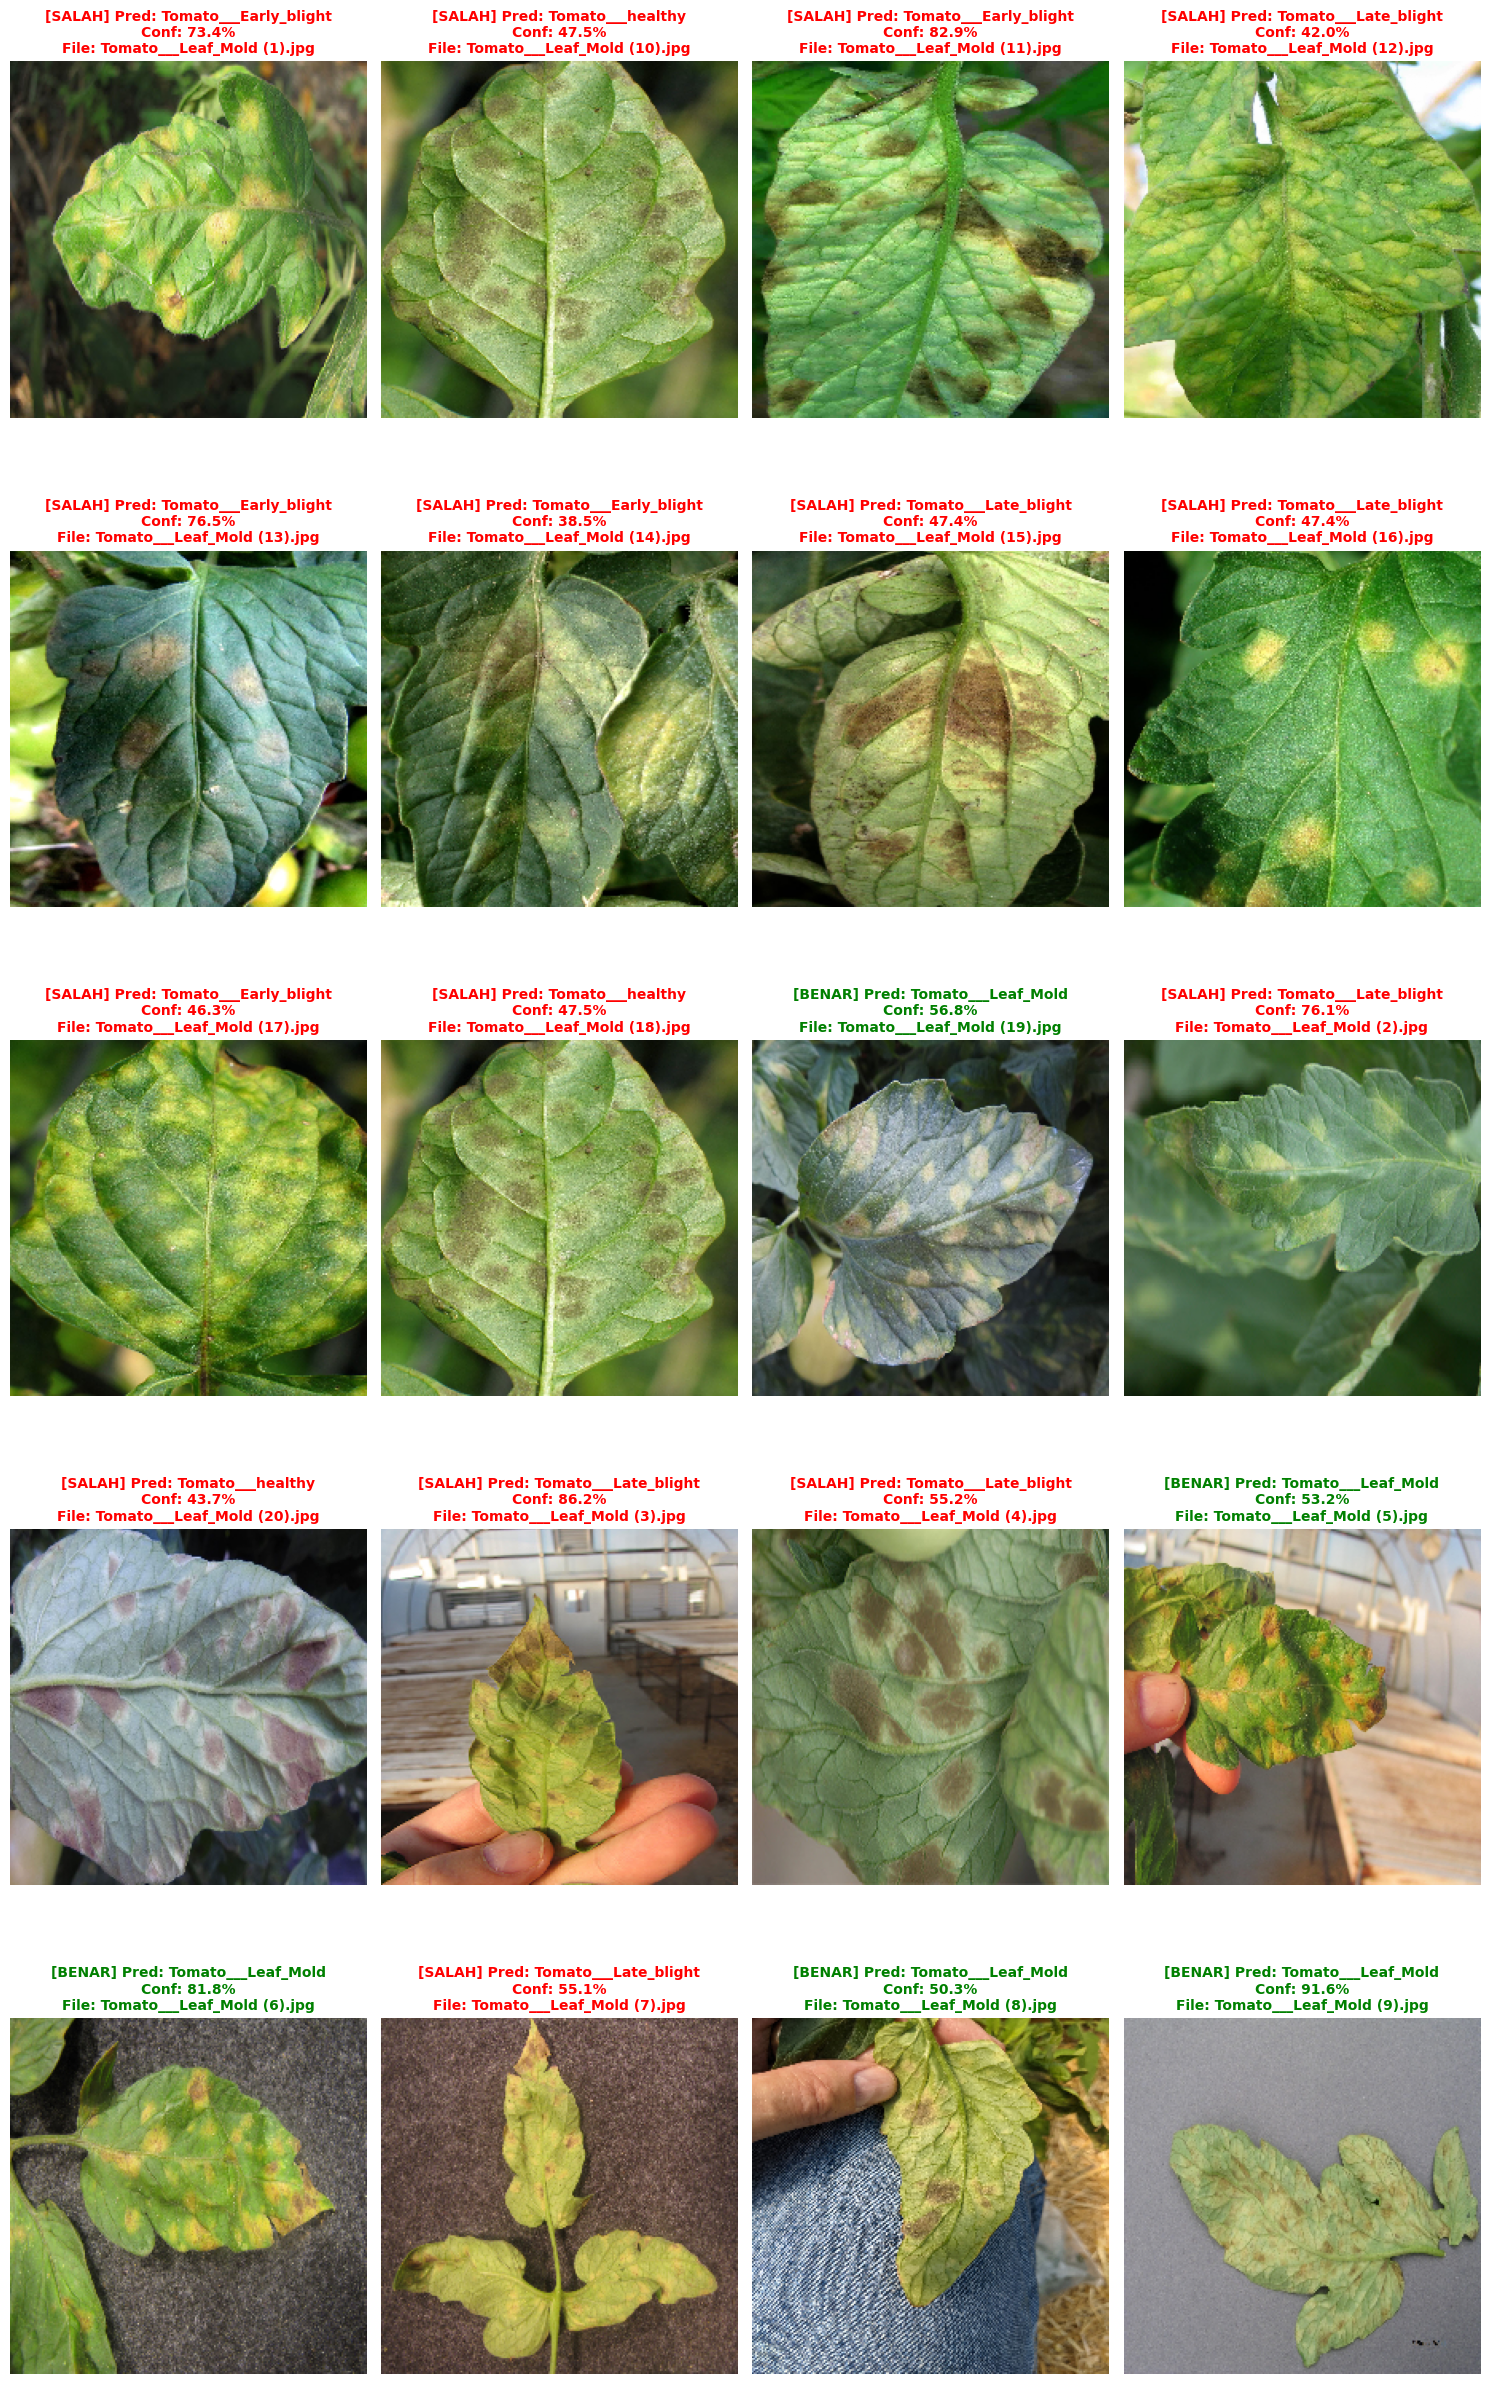

In [ ]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

# ===============================================================
# KONFIGURASI TARGET
# ===============================================================
TARGET_CLASS_NAME = "Tomato___Leaf_Mold"  # Pastikan string ini sama persis dengan nama file/kelas

def visualize_all_images_in_class(target_class):
    # 1. Cari semua file yang mengandung nama kelas target
    # Kita gunakan logika 'in' agar lebih aman menangkap nama file
    all_files = sorted(os.listdir(test_dir)) # Sorted agar urutan konsisten
    target_files = [f for f in all_files if target_class in f]
    
    total_found = len(target_files)
    print(f"🔎 Ditemukan {total_found} gambar untuk kelas '{target_class}' (Sesuai Matrix: 20).")
    
    if total_found == 0:
        print("⚠ Tidak ada file ditemukan. Cek kembali 'TARGET_CLASS_NAME' atau nama file di folder.")
        return

    # 2. Setup Grid Plot Dinamis (Agar muat 20 gambar)
    cols = 4 # 4 Gambar per baris
    rows = math.ceil(total_found / cols) # Hitung jumlah baris otomatis
    
    plt.figure(figsize=(15, 5 * rows)) # Tinggi gambar menyesuaikan jumlah baris
    
    print("⏳ Sedang memproses prediksi... Mohon tunggu.")
    
    for i, fname in enumerate(target_files):
        img_path = os.path.join(test_dir, fname)
        
        try:
            # A. Load & Preprocess
            img = load_img(img_path, target_size=IMG_SIZE)
            img_arr = img_to_array(img)
            img_pre = preprocess_input(img_arr)
            img_batch = np.expand_dims(img_pre, axis=0)
            
            # B. Prediksi
            probs = model.predict(img_batch, verbose=0)[0]
            pred_idx = np.argmax(probs)
            confidence = np.max(probs) * 100
            pred_label = class_names[pred_idx]
            
            # C. Cek Benar/Salah
            # Karena kita memfilter file 'Leaf Mold', maka True Label pasti 'Leaf Mold'
            is_correct = (pred_label == target_class)
            
            # Warna & Status
            if is_correct:
                color = 'green'
                status = "BENAR"
            else:
                color = 'red'
                status = "SALAH"
            
            # D. Plotting
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img_to_array(img) / 255.0)
            
            # Teks Judul
            title_text = (f"[{status}] Pred: {pred_label}\n"
                          f"Conf: {confidence:.1f}%\n"
                          f"File: {fname}")
            
            plt.title(title_text, color=color, fontsize=10, fontweight='bold')
            plt.axis("off")
            
        except Exception as e:
            print(f"Error pada file {fname}: {e}")

    plt.tight_layout()
    plt.show()

# Jalankan Fungsi
visualize_all_images_in_class(TARGET_CLASS_NAME)

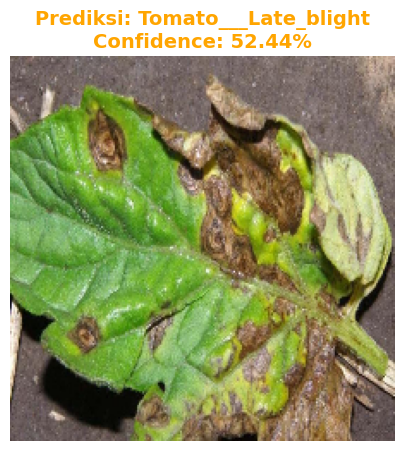

✅ File: D:\SEMESTER_7\PCD\Clasiffication\Dataset\test123.jpeg
🔍 Hasil: Tomato___Late_blight
📊 Kepastian: 52.44%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

def predict_single_image(image_path, model, class_names):
    """
    Fungsi untuk memprediksi satu gambar.
    Args:
        image_path (str): Lokasi file gambar.
        model (tf.keras.Model): Model yang sudah dilatih.
        class_names (list): Daftar nama kelas.
    """
    try:
        # 1. Load dan Resize Gambar
        # Target size harus SAMA PERSIS dengan CONFIG['img_size'] saat training (224, 224)
        img = load_img(image_path, target_size=(224, 224))
        
        # 2. Ubah ke Array
        img_array = img_to_array(img)
        
        # 3. Tambahkan Dimensi Batch
        # Model mengharapkan input (Batch, Height, Width, Channel) -> (1, 224, 224, 3)
        img_batch = np.expand_dims(img_array, axis=0)
        
        # 4. Prediksi
        # Kita TIDAK perlu membagi 255 manual karena layer 'preprocess_input'
        # sudah ada di dalam model Anda.
        predictions = model.predict(img_batch, verbose=0)
        
        # 5. Ambil Hasil
        score = tf.nn.softmax(predictions[0]) # Mengubah output menjadi probabilitas
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class = class_names[predicted_class_idx]
        confidence = np.max(predictions[0]) * 100
        
        # 6. Visualisasi
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        
        # Judul dengan warna: Hijau jika confidence tinggi (>80%), Kuning jika ragu
        title_color = 'green' if confidence > 80 else 'orange'
        
        plt.title(f"Prediksi: {predicted_class}\nConfidence: {confidence:.2f}%", 
                  color=title_color, fontsize=14, fontweight='bold')
        plt.show()
        
        print(f"✅ File: {image_path}")
        print(f"🔍 Hasil: {predicted_class}")
        print(f"📊 Kepastian: {confidence:.2f}%")
        
        return predicted_class, confidence

    except Exception as e:
        print(f"❌ Error: Gagal memproses gambar. {e}")
        return None, None

# ===============================================================
# CARA PENGGUNAAN
# ===============================================================

# Ganti string di bawah ini dengan lokasi file gambar yang ingin dites
# Contoh: "C:/Downloads/daun_tomat_test.jpg" atau "../Dataset/test/file_01.jpg"
lokasi_file_gambar = "D:\\SEMESTER_7\\PCD\\Clasiffication\\Dataset\\test123.jpeg" 

# Pastikan file ada sebelum menjalankan
import os
if os.path.exists(lokasi_file_gambar):
    predict_single_image(lokasi_file_gambar, model, class_names)
else:
    print(f"File tidak ditemukan di: {lokasi_file_gambar}")


🔍 EVALUASI FINAL DATA TEST

🏆 TEST ACCURACY: 67.50%
                       precision    recall  f1-score   support

Tomato___Early_blight       0.61      0.70      0.65        20
 Tomato___Late_blight       0.54      0.75      0.62        20
   Tomato___Leaf_Mold       1.00      0.25      0.40        20
     Tomato___healthy       0.83      1.00      0.91        20

             accuracy                           0.68        80
            macro avg       0.74      0.68      0.65        80
         weighted avg       0.74      0.68      0.65        80



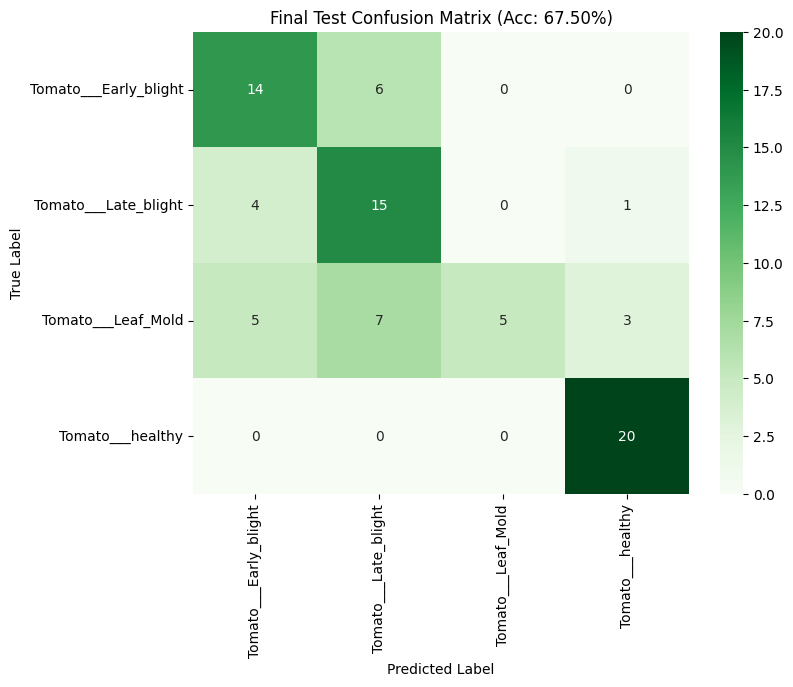

: 

In [ ]:
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

print("\n" + "="*40)
print("🔍 EVALUASI FINAL DATA TEST")
print("="*40)

# List file test
test_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
y_true = []
y_pred = []
class_names = list(train_generator.class_indices.keys())

# Loop Prediksi
for fname in test_files:
    # Ambil label asli dari nama file
    label_str = fname.split(" ")[0] 
    
    if label_str in class_names:
        # Simpan Label Asli
        y_true.append(class_names.index(label_str))
        
        # Prediksi
        img_path = os.path.join(test_dir, fname)
        img = load_img(img_path, target_size=IMG_SIZE)
        img_arr = img_to_array(img)
        img_pre = preprocess_input(img_arr)
        img_batch = np.expand_dims(img_pre, axis=0)
        
        prediction = model.predict(img_batch, verbose=0)
        y_pred.append(np.argmax(prediction))

# Hitung Akurasi
acc_test = np.mean(np.array(y_true) == np.array(y_pred)) * 100
print(f"\n🏆 TEST ACCURACY: {acc_test:.2f}%")

# Tampilkan Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Tampilkan Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Final Test Confusion Matrix (Acc: {acc_test:.2f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()